# **Entrenamiento del modelo con Random Forest**
>"Random Forest es un sólido algoritmo de aprendizaje automático que se puede utilizar para una variedad de tareas, incluidas la regresión y la clasificación" (Wood, 2020)

Random Forest es una elección ideal para este proyecto por su robustez, capacidad para manejar datos complejos y desbalanceados, y facilidad para interpretar resultados.

## Importar librerias necesarias para el modelo de entrenamiento
Se importan las bibliotecas requeridas para cargar datos, entrenar el modelo, evaluar su rendimiento y guardar el modelo para uso posterior.

In [1]:
# Importar bibliotecas necesarias
import pandas as pd  # Para manipulación de datos
import numpy as np  # Operaciones numéricas
import seaborn as sns  # Visualización de datos
import matplotlib.pyplot as plt  # Gráficos
import joblib  # Para guardar el modelo entrenado
from sklearn.metrics import ConfusionMatrixDisplay  # Visualización de matriz de confusión
from sklearn.model_selection import train_test_split  # División de datos en entrenamiento/prueba
from sklearn.ensemble import RandomForestClassifier  # Modelo Random Forest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # Métricas de evaluación
from sklearn.preprocessing import StandardScaler  # Escalado de características

## Cargar los Datos Preparados
> Si has cambiado de ruta o entorno, remplaza la ruta al conjunto de datos preparados
- Carga los datos preparados en un DataFrame.
- Verifica si hay valores nulos y los rellena con 0 en caso necesario.
- Esto asegura que el conjunto de datos esté limpio antes del entrenamiento.

In [2]:
# Cargar los datos preparados
# Debes cargar el conjunto de datos Preparado y que su nombre sea correcto
file_path = 'c:/Users/Sr. Sebastian/Documents/GitHub/CRMIA/app/ia/churn_model/data_export_churn_service.csv'
data = pd.read_csv(file_path)

# Inspección inicial
print("Primeras filas del conjunto de datos:")
print(data.head())

# Verificar valores nulos
print("\nValores nulos por columna:")
print(data.isnull().sum())

# Llenar valores nulos (si aplica)
data.fillna(0, inplace=True)

Primeras filas del conjunto de datos:
   id  time_since_last_purchase  purchase_frequency  average_order_value  \
0   1                       829            0.482498             134442.0   
1   2                      1759            0.067340             365316.0   
2   3                       147            0.165746             188265.0   
3   4                       394            0.119237             148092.0   
4   5                      1829            0.010787             110279.4   

   total_purchases  recent_activity  total_interactions  \
0               17              3.0                  48   
1                6              5.0                  92   
2                5              3.0                  84   
3                5              2.0                  37   
4                1              2.0                  51   

   monthly_avg_purchases  churn  
0               0.482498      1  
1               0.067340      1  
2               0.165746      1  
3             

## Separar Características y Etiquetas
>- X: Contiene las características que el modelo usará para hacer predicciones.

>- y: Es la etiqueta objetivo (si un cliente abandonó o no).

División: Se separan los datos en conjuntos de entrenamiento y prueba en proporción 80%-20% (Recomendado).

In [3]:
# 2. Separar características (X) y etiquetas (y)
X = data.drop(columns=['churn', 'id'])  # Características (features)
y = data['churn']  # Etiqueta objetivo (target)

# División en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Entrenar el Modelo
> Se utiliza Random Forest, un modelo robusto y flexible para clasificación.

In [4]:
# 3. Entrenar un modelo Random Forest
model = RandomForestClassifier(
    n_estimators=100,        # Número de árboles en el bosque
    max_depth=10,            # Profundidad máxima de los árboles
    random_state=42,         # Semilla para reproducibilidad
    class_weight='balanced'  # Manejo de desbalanceo en clases
)

print("\nEntrenando el modelo...")
model.fit(X_train, y_train)


Entrenando el modelo...


RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

## Evaluación del Modelo
- Matriz de confusión: Muestra el rendimiento del modelo en términos de verdaderos positivos, falsos positivos, etc.
- Reporte de clasificación: Incluye métricas como precisión, recall y F1-score.
- Precisión: Proporción de predicciones correctas.

In [5]:
# Predicciones
y_pred = model.predict(X_test)

# Métricas de evaluación
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy*100:.1f}%")


Matriz de confusión:
[[18  0]
 [ 0 92]]
Precisión del modelo: 100.0%


## **Interpretacion de Precicion del Modelo de Prediccion de Abandono**
## Metricas de Evaluacion
- Matriz de confucion

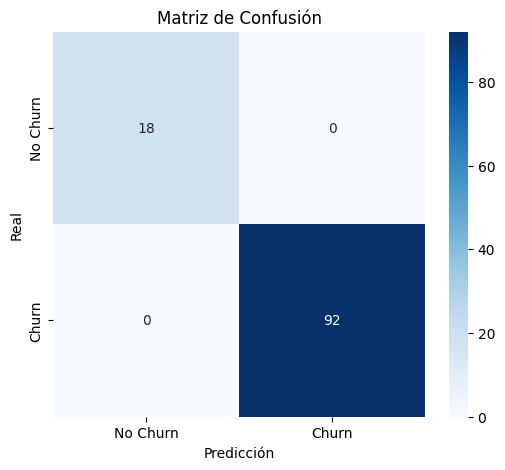

In [6]:
# Crear la matriz de confusión
matrix = confusion_matrix(y_test, y_pred)

# Visualizar la matriz
plt.figure(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


## Como entende el grafico
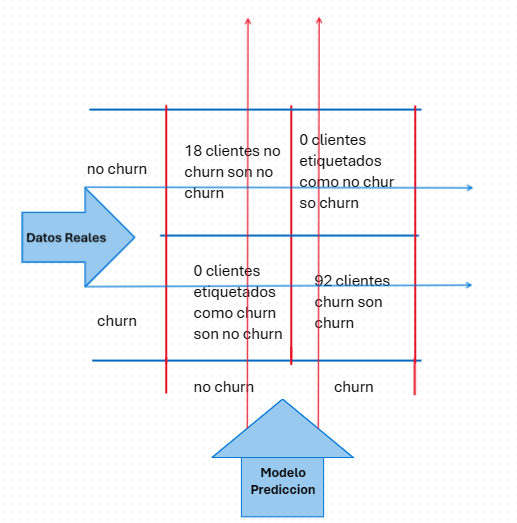

## Aplicacion de Características
- Identifica qué características son más importantes para las decisiones del modelo.
- Esto puede guiar estrategias de negocio o análisis adicional.

In [7]:
# Importancia de características
importances = model.feature_importances_
feature_names = X.columns

print("\nImportancia de las características en el modelo de prediccion:")
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance*100:.1f}%")


Importancia de las características en el modelo de prediccion:
time_since_last_purchase: 64.7%
purchase_frequency: 10.2%
average_order_value: 1.8%
total_purchases: 5.5%
recent_activity: 2.1%
total_interactions: 6.5%
monthly_avg_purchases: 9.0%


# **Pruebas**
- Genera predicciones para nuevos clientes basándose en las mismas características utilizadas en el entrenamiento.
- Calcula las probabilidades de abandono (Churn) y no abandono (No Churn).

In [10]:
# Prueba con nuevos datos
new_data = pd.DataFrame({
    'time_since_last_purchase': [13], # Tiempo desde la última compra
    'purchase_frequency': [20.5],     # Frecuencia de compra
    'average_order_value': [53000],     # Valor promedio de compra
    'total_purchases': [6],           # Total de compras
    'recent_activity': [7],           # Actividad reciente (ultimos 90 días)
    'total_interactions': [7],        # Total de interacciones
    'monthly_avg_purchases': [0.58]   # Promedio mensual de compras
})

# Predicción binaria
prediction = model.predict(new_data)

# Probabilidad de abandono
probabilities = model.predict_proba(new_data)

# Mostrar resultados
print("\nPredicción para un nuevo cliente:")
print(f"Churn: {prediction[0]}")

print("\nProbabilidades:")
print(f"Probabilidad de no Abandono(0): {100*probabilities[0][0]}%")
print(f"Probabilidad de Abandono (1): {100*probabilities[0][1]}%")



Predicción para un nuevo cliente:
Churn: 0

Probabilidades:
Probabilidad de no Abandono(0): 95.0%
Probabilidad de Abandono (1): 5.0%


## Exportar el Modelo
> Guarda el modelo entrenado en un archivo para su uso

In [8]:
# Exportar el modelo entrenado
joblib.dump(model, 'churn_model.pkl')
print("\nEl modelo ha sido guardado como 'churn_model.pkl'.")


El modelo ha sido guardado como 'churn_model.pkl'.
